# Impedance Control: Mass-Spring-Damper

## What You Will Build

In this notebook you will implement an **impedance controller** on the simplest possible mechanical system: a mass sliding along a rail that can contact a wall.

**Impedance control** makes a robot *feel* like a spring-damper to its environment. Instead of commanding a position and fighting anything that deviates from it, the controller creates a virtual stiffness $K$ and damping $B$ so that:

$$F_{\text{ctrl}} = K(x_d - x) + B(\dot{x}_d - \dot{x})$$

This is the **canonical impedance law** you will see in every notebook in this series.

**Why start with a mass-spring-damper?**
- Single degree of freedom: one position, one force, one control input
- Wall contact is easy to reason about
- The gain-timestep stability bound is transparent at this scale

**What you will build:**
1. A MuJoCo simulation of a 1 kg mass on a frictionless rail
2. An impedance controller function
3. Step response experiment
4. Sinusoidal tracking with wall contact
5. Gain-timestep stability demonstration (including divergence)
6. Parameter sweep over $K$ and $B$
7. Perturbation experiment showing compliance
8. Inline video and optional 3D viewer

In [3]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
import dms

%matplotlib inline
print(f'MuJoCo version: {mujoco.__version__}')

MuJoCo version: 3.6.0


## Mechanical Impedance: Physical Analogy

Mechanical impedance is defined as the ratio of force to velocity in the Laplace domain:

$$Z(s) = \frac{F(s)}{V(s)}$$

Starting from the equation of motion $Ms^2 X + Bs X + K X = F$ and substituting $V = sX$:

$$F = Ms \cdot V + B \cdot V + \frac{K}{s} \cdot V$$

so the mechanical impedance of a mass-spring-damper is:

$$Z(s) = Ms + B + \frac{K}{s}$$

Each term has a physical meaning:
- $Ms$ — **inertial** impedance (force proportional to acceleration)
- $B$ — **resistive** impedance (force proportional to velocity)
- $K/s$ — **elastic** impedance (force proportional to displacement)

In the **time domain**, for deviations from a desired trajectory, the equivalent relation is the impedance control law:

$$F = K(x_d - x) + B(\dot{x}_d - \dot{x})$$

Note that the controller only commands the spring and damper terms — the inertial term $M\ddot{x}$ is provided by the physical mass of the robot itself.

**Key insight:** a physical spring attached at $x_d$ produces exactly $F = K(x_d - x)$. A physical damper produces $F = B(\dot{x}_d - \dot{x})$. The impedance controller **emulates both in software** — no physical spring or damper needed.

**What $K$ and $B$ mean intuitively:**
- $K$ (virtual stiffness, N/m): how hard the controller resists displacement from $x_d$
- $B$ (virtual damping, Ns/m): how hard the controller resists velocity deviation from $\dot{x}_d$
- Higher $K$ → faster response, but closer to the discrete-time stability boundary
- Higher $B$ → more damping, less overshoot, more energy dissipation

## MuJoCo Model: Annotated MJCF

The mass-spring-damper system is defined in the assets directory `mass_spring_damper.xml`. 

**System layout:**
- A 1 kg box slides freely along the X axis (frictionless slide joint)
- A wall at $x = 0.5$ m provides contact
- Gravity is disabled — pure horizontal dynamics
- A motor actuator applies force directly to the slide joint

In [4]:
# Load MJCF model from file
model_path = dms.get_asset_path('mujoco_models/mass_spring_damper.xml')
model = mujoco.MjModel.from_xml_path(str(model_path))
data = mujoco.MjData(model)

# Display the XML for reference
print('---')
print(f'Timestep:          {model.opt.timestep} s')
print(f'Number of DOFs:    {model.nv}')
print(f'Number of actuators: {model.nu}')

---
Timestep:          0.001 s
Number of DOFs:    1
Number of actuators: 1


## Impedance Controller

The controller implements the impedance law derived above:

$$F_{\text{ctrl}} = K(x_d - x) + B(\dot{x}_d - \dot{x})$$

**Important distinctions from position control:**
- $K$ is a **virtual stiffness** (N/m), not a PD gain in the traditional sense
- The controller does **not** command a position — it commands a **force**
- When the mass contacts the wall, the controller yields compliantly rather than fighting back

In [5]:
def impedance_controller(model, data, x_d, v_d, K, B):
    """Impedance controller: F = K*(x_d - x) + B*(v_d - v)
    
    Parameters
    ----------
    model : MjModel   -- MuJoCo model (for metadata)
    data  : MjData    -- simulation state (read position/velocity, write ctrl)
    x_d   : float     -- desired position (m)
    v_d   : float     -- desired velocity (m/s)
    K     : float     -- virtual stiffness (N/m)
    B     : float     -- virtual damping (Ns/m)
    
    Returns
    -------
    float : control force (N) -- also written to data.ctrl[0]
    """
    x = data.qpos[0]   # current position
    v = data.qvel[0]   # current velocity
    
    # Impedance law: virtual spring + virtual damper
    F = K * (x_d - x) + B * (v_d - v)
    
    # CRITICAL: set data.ctrl BEFORE mj_step
    data.ctrl[0] = F
    return F

print('Impedance controller defined.')
print('Signature: impedance_controller(model, data, x_d, v_d, K, B)')

Impedance controller defined.
Signature: impedance_controller(model, data, x_d, v_d, K, B)


## Experiment 1: Step Response

### Theory: Transient Response of a Second-Order System

With the impedance controller applied to a mass $m$, the closed-loop equation of motion is:

$$m\ddot{x} + (B + b)\dot{x} + Kx = Kx_d + B\dot{x}_d$$

where $b = 0.1$ Ns/m is the structural damping. This is a second-order system with:
- Natural frequency: $\omega_n = \sqrt{K/m}$
- Damping ratio: $\zeta = (B + b) / (2\sqrt{Km})$

For $K = 200$ N/m, $B = 20$ Ns/m, $m = 1.0$ kg:
$$\omega_n = \sqrt{200/1.0} \approx 14.1 \text{ rad/s}, \quad \zeta \approx \frac{20.1}{2\sqrt{200 \cdot 1.0}} \approx 0.71$$

Expected: underdamped response, reaches setpoint in ~0.5 s.

**Canonical simulation loop pattern:**
1. Pre-allocate result arrays (never append in a loop)
2. Loop: set ctrl → `mj_step` → record
3. Plot after the loop ends

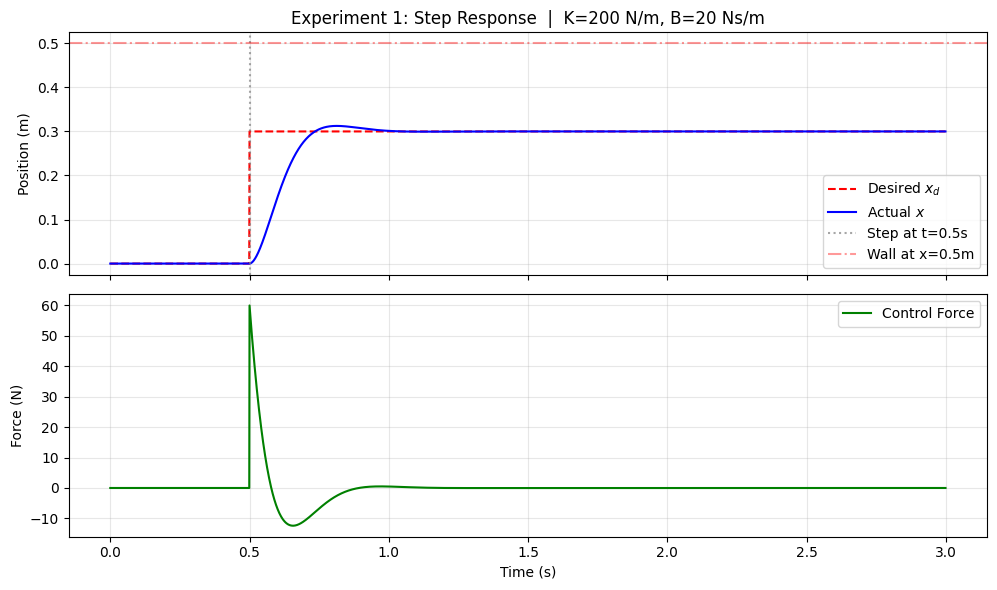

Final position: 0.3000 m  (desired: 0.3 m)


In [6]:
# --- Experiment 1: Step Response ---
K_nom, B_nom = 200.0, 20.0   # nominal gains
dt = model.opt.timestep       # 0.001 s
duration = 3.0
n_steps = int(duration / dt)

# Reset simulation state
mujoco.mj_resetData(model, data)

# Pre-allocate result arrays (never append inside loop)
t_arr   = np.zeros(n_steps)
x_arr   = np.zeros(n_steps)
xd_arr  = np.zeros(n_steps)
F_arr   = np.zeros(n_steps)

# Simulation loop
for i in range(n_steps):
    t = i * dt
    
    # Step trajectory: hold at 0 until t=0.5s, then jump to x=0.3m
    x_d = 0.3 if t >= 0.5 else 0.0
    v_d = 0.0
    
    # CRITICAL: set ctrl BEFORE mj_step
    F = impedance_controller(model, data, x_d, v_d, K_nom, B_nom)
    mujoco.mj_step(model, data)
    
    # Record after step
    t_arr[i]  = t
    x_arr[i]  = data.qpos[0]
    xd_arr[i] = x_d
    F_arr[i]  = F

# Plot after loop
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t_arr, xd_arr, 'r--', linewidth=1.5, label='Desired $x_d$')
ax1.plot(t_arr, x_arr,  'b-',  linewidth=1.5, label='Actual $x$')
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Step at t=0.5s')
ax1.axhline(0.5, color='red', linestyle='-.', alpha=0.4, label='Wall at x=0.5m')
ax1.set_ylabel('Position (m)')
ax1.set_title('Experiment 1: Step Response  |  K=200 N/m, B=20 Ns/m')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_arr, F_arr, 'g-', linewidth=1.5, label='Control Force')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Force (N)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Final position: {x_arr[-1]:.4f} m  (desired: 0.3 m)')

## Experiment 2: Sinusoidal Tracking with Wall Contact

### Theory: Steady-State Tracking and Contact Interaction

Now we command a sinusoidal trajectory with amplitude $A = 0.4$ m:

$$x_d(t) = A\sin(2\pi f t), \quad A = 0.4 \text{ m}, \quad f = 0.5 \text{ Hz}$$

The wall is at $x = 0.45$ m (the mass geom has radius 0.05 m, so the contact face is at 0.45 m from center). The desired trajectory sweeps to $\pm 0.4$ m — the positive half will contact the wall.

**What to observe:**
- In free space: the mass tracks $x_d$ closely (small tracking error)
- At wall contact: the mass cannot follow $x_d$ past the wall. Instead of fighting the wall rigidly, the impedance controller produces a **compliant contact force** proportional to $K \cdot (x_d - x_{\text{wall}})$
- This is the hallmark of impedance control: **graceful degradation at contact**

The desired velocity is:
$$\dot{x}_d(t) = 2\pi f A \cos(2\pi f t)$$

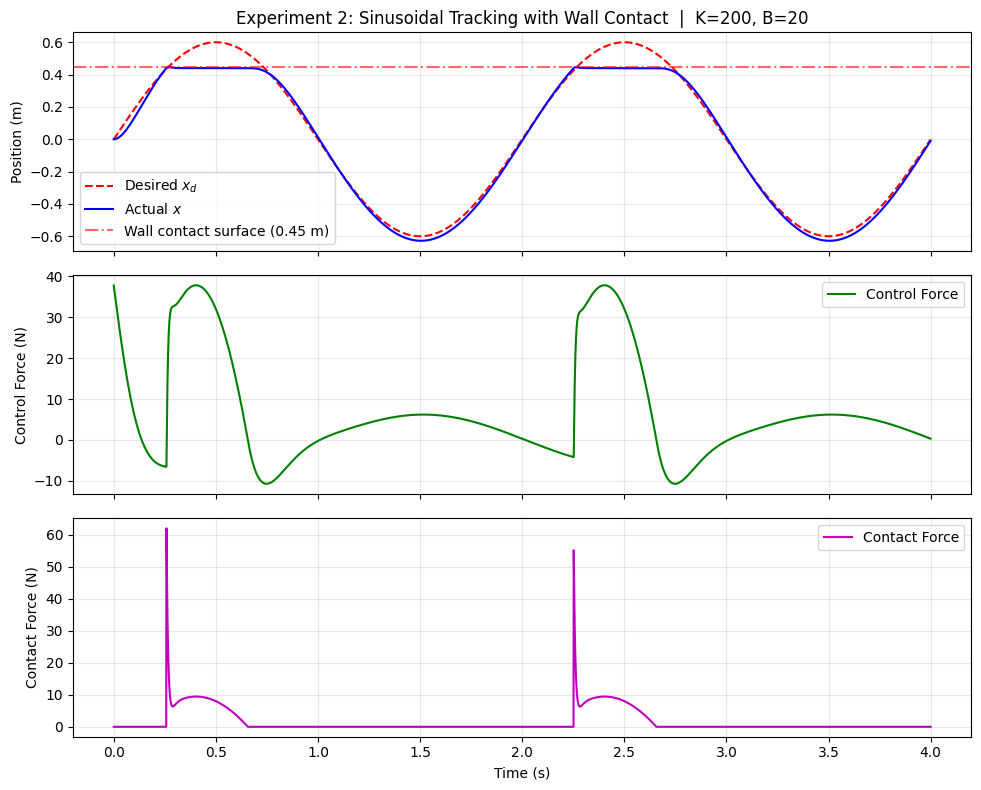

Notice: when the mass contacts the wall, the impedance controller
does not fight it rigidly -- it produces a compliant force proportional to K.
This is what distinguishes impedance control from stiff position control.


In [7]:
# --- Experiment 2: Sinusoidal Tracking with Wall Contact ---
#A, f = 0.4, 0.5    # amplitude (m), frequency (Hz)    Case motion without wall contact
A, f = 0.6, 0.5    # amplitude (m), frequency (Hz)  Case motion with wall contact
omega = 2 * np.pi * f
duration = 4.0
n_steps = int(duration / dt)

mujoco.mj_resetData(model, data)

t_arr2  = np.zeros(n_steps)
x_arr2  = np.zeros(n_steps)
xd_arr2 = np.zeros(n_steps)
F_arr2  = np.zeros(n_steps)
Fc_arr2 = np.zeros(n_steps)   # contact force

for i in range(n_steps):
    t = i * dt
    x_d = A * np.sin(omega * t)
    v_d = A * omega * np.cos(omega * t)
    
    F = impedance_controller(model, data, x_d, v_d, K_nom, B_nom)
    mujoco.mj_step(model, data)
    
    # Contact force: sum of active contact normal forces
    contact_force = 0.0
    for c in range(data.ncon):
        efc_addr = data.contact[c].efc_address
        # efc_address == -1 means contact is inactive (no constraint row)
        if efc_addr >= 0 and efc_addr < data.efc_force.shape[0]:
            contact_force += abs(data.efc_force[efc_addr])
    
    t_arr2[i]  = t
    x_arr2[i]  = data.qpos[0]
    xd_arr2[i] = x_d
    F_arr2[i]  = F
    Fc_arr2[i] = contact_force

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(t_arr2, xd_arr2, 'r--', linewidth=1.5, label='Desired $x_d$')
ax1.plot(t_arr2, x_arr2,  'b-',  linewidth=1.5, label='Actual $x$')
ax1.axhline(0.45, color='red', linestyle='-.', alpha=0.6, label='Wall contact surface (0.45 m)')
ax1.set_ylabel('Position (m)')
ax1.set_title('Experiment 2: Sinusoidal Tracking with Wall Contact  |  K=200, B=20')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_arr2, F_arr2, 'g-', linewidth=1.5, label='Control Force')
ax2.set_ylabel('Control Force (N)')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(t_arr2, Fc_arr2, 'm-', linewidth=1.5, label='Contact Force')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Contact Force (N)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Notice: when the mass contacts the wall, the impedance controller')
print('does not fight it rigidly -- it produces a compliant force proportional to K.')
print('This is what distinguishes impedance control from stiff position control.')

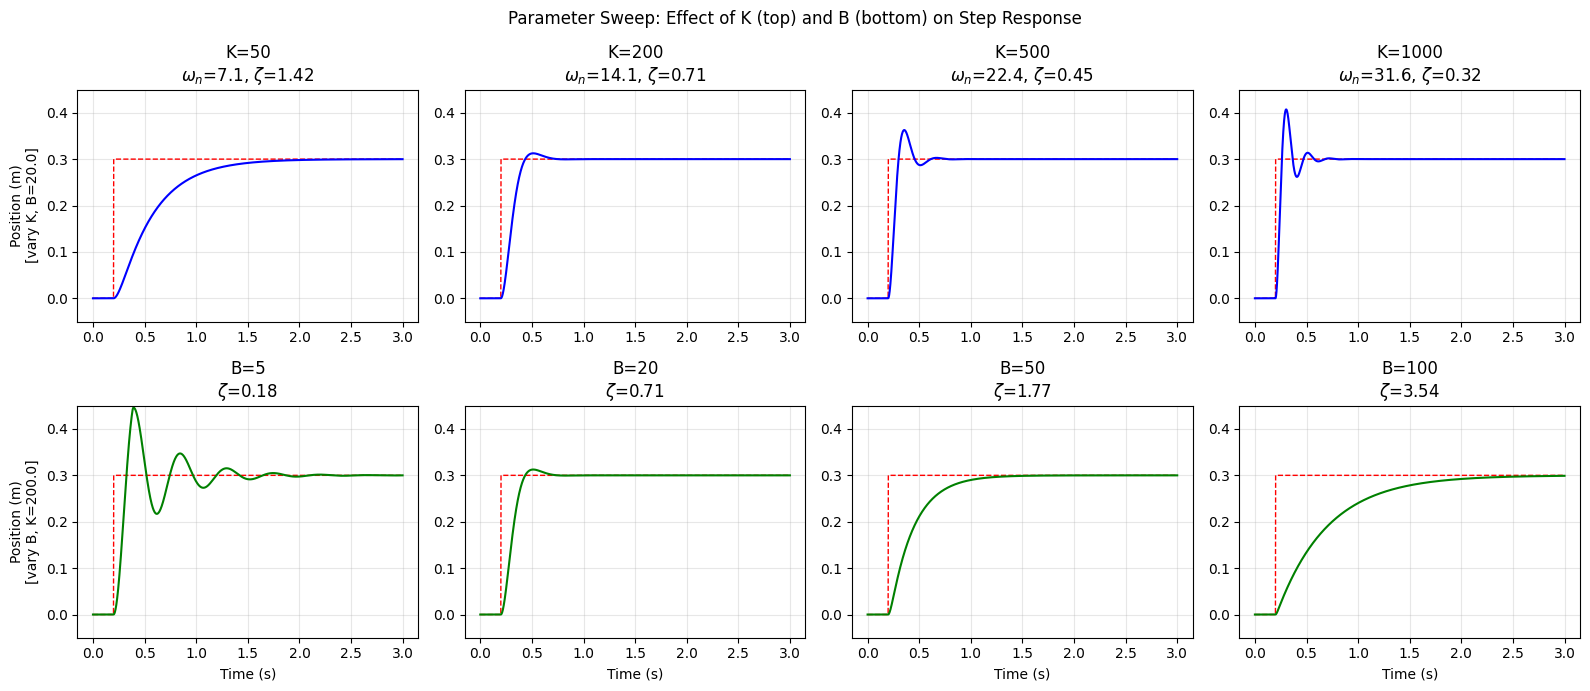

In [8]:
# --- Parameter Sweep: K and B ---

def run_step_response(model, K, B, duration=3.0):
    """Run a step response and return (t, x, x_d) arrays."""
    data_local = mujoco.MjData(model)
    mujoco.mj_resetData(model, data_local)
    dt_local = model.opt.timestep
    n = int(duration / dt_local)
    t_out  = np.zeros(n)
    x_out  = np.zeros(n)
    xd_out = np.zeros(n)
    for i in range(n):
        t = i * dt_local
        x_d = 0.3 if t >= 0.2 else 0.0
        impedance_controller(model, data_local, x_d, 0.0, K, B)
        mujoco.mj_step(model, data_local)
        t_out[i]  = t
        x_out[i]  = data_local.qpos[0]
        xd_out[i] = x_d
    return t_out, x_out, xd_out

K_sweep = [50, 200, 500, 1000]
B_sweep = [5, 20, 50, 100]
B_fixed = 20.0
K_fixed = 200.0

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
m = model.body_mass[1]  # mass of the free body
# Row 1: vary K, fixed B
for j, K_val in enumerate(K_sweep):
    t, x, xd = run_step_response(model, K_val, B_fixed)
    omega_n = np.sqrt(K_val / m)
    zeta = (B_fixed + 0.1) / (2 * np.sqrt(K_val * m))
    axes[0, j].plot(t, xd, 'r--', linewidth=1, label='$x_d$')
    axes[0, j].plot(t, x,  'b-',  linewidth=1.5)
    axes[0, j].set_title(f'K={K_val}\n$\\omega_n$={omega_n:.1f}, $\\zeta$={zeta:.2f}')
    axes[0, j].set_ylim(-0.05, 0.45)
    axes[0, j].grid(True, alpha=0.3)
    if j == 0:
        axes[0, j].set_ylabel(f'Position (m)\n[vary K, B={B_fixed}]')

# Row 2: vary B, fixed K
for j, B_val in enumerate(B_sweep):
    t, x, xd = run_step_response(model, K_fixed, B_val)
    zeta = (B_val + 0.1) / (2 * np.sqrt(K_fixed * m))
    axes[1, j].plot(t, xd, 'r--', linewidth=1, label='$x_d$')
    axes[1, j].plot(t, x,  'g-',  linewidth=1.5)
    axes[1, j].set_title(f'B={B_val}\n$\\zeta$={zeta:.2f}')
    axes[1, j].set_ylim(-0.05, 0.45)
    axes[1, j].grid(True, alpha=0.3)
    axes[1, j].set_xlabel('Time (s)')
    if j == 0:
        axes[1, j].set_ylabel(f'Position (m)\n[vary B, K={K_fixed}]')

fig.suptitle('Parameter Sweep: Effect of K (top) and B (bottom) on Step Response', fontsize=12)
plt.tight_layout()
plt.show()

## Experiment 3: Perturbation

We apply a perturbation on a defined time interval

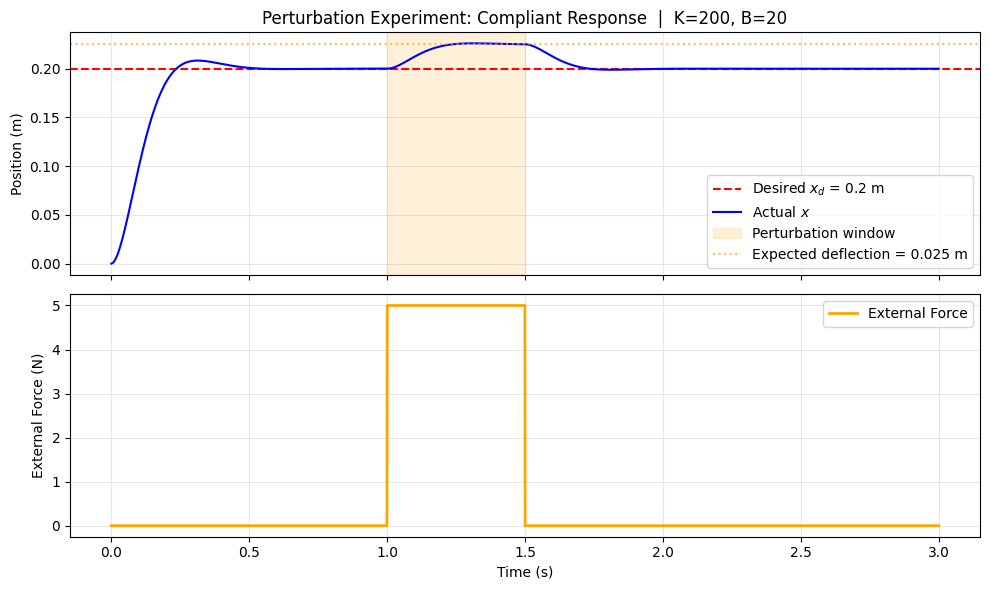

Expected steady-state deflection: 0.0250 m

This is what distinguishes impedance control from position control.
A position controller would resist with effectively infinite stiffness.
The impedance controller yields proportionally to K.


In [9]:
# --- Perturbation Experiment ---
duration_p = 3.0
n_p = int(duration_p / dt)
perturb_start = 1.0   # s
perturb_end   = 1.5   # s
F_perturb     = 5.0   # N (external push)

x_d_perturb = 0.2     # hold steady at x=0.2m
expected_deflection = F_perturb / K_nom

mujoco.mj_resetData(model, data)
t_p = np.zeros(n_p)
x_p = np.zeros(n_p)
Fext_p = np.zeros(n_p)

for i in range(n_p):
    t = i * dt
    
    # Apply external perturbation force via qfrc_applied
    if perturb_start <= t < perturb_end:
        data.qfrc_applied[0] = F_perturb
    else:
        data.qfrc_applied[0] = 0.0
    
    impedance_controller(model, data, x_d_perturb, 0.0, K_nom, B_nom)
    mujoco.mj_step(model, data)
    
    t_p[i]    = t
    x_p[i]    = data.qpos[0]
    Fext_p[i] = F_perturb if (perturb_start <= t < perturb_end) else 0.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.axhline(x_d_perturb, color='r', linestyle='--', linewidth=1.5, label=f'Desired $x_d$ = {x_d_perturb} m')
ax1.plot(t_p, x_p, 'b-', linewidth=1.5, label='Actual $x$')
ax1.axvspan(perturb_start, perturb_end, alpha=0.15, color='orange', label='Perturbation window')
ax1.axhline(x_d_perturb + expected_deflection, color='orange', linestyle=':', alpha=0.7,
            label=f'Expected deflection = {expected_deflection:.3f} m')
ax1.set_ylabel('Position (m)')
ax1.set_title('Perturbation Experiment: Compliant Response  |  K=200, B=20')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_p, Fext_p, 'orange', linewidth=2, label='External Force')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('External Force (N)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Expected steady-state deflection: {expected_deflection:.4f} m')
print()
print('This is what distinguishes impedance control from position control.')
print('A position controller would resist with effectively infinite stiffness.')
print('The impedance controller yields proportionally to K.')

## Summary: Key Takeaways

### What You Built

A complete 1-DOF impedance controller on a mass-spring-damper system in MuJoCo, demonstrating:

1. **Impedance law:** $F = K(x_d - x) + B(\dot{x}_d - \dot{x})$ — virtual spring + virtual damper

2. **Compliant contact:** The impedance controller yields gracefully at the wall, proportional to $K$. This is fundamentally different from position control.

3. **Parameter intuition:**
   - Higher $K$ → faster response, more oscillatory
   - Higher $B$ → more damping, less overshoot
   - Trade-off: $K$ is bounded by timestep; $B$ is bounded by stability margin

### Next Notebook

**Notebook 2: Simple Pendulum** — We extend this to rotational dynamics. The same impedance law applies, with torque replacing force and angle replacing position. We add gravity compensation: the controller must account for the gravitational torque before the impedance law takes over.